In [1]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors as colors
import torch

In [2]:
from torchvision.transforms.functional import hflip,vflip

In [3]:
print(torch.__version__)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

1.13.0


device(type='cuda')

In [4]:
import matplotlib as mpl
mpl.rcParams["font.size"] = 18
mpl.rcParams['axes.titlesize'] = 18

In [5]:
import os
import time                   
import sys
import argparse 

In [6]:
remove_im_mean = lambda data : data - data.mean(dim=(1,2,3),keepdims=True )
def im_set_corr(set1, set2, remove_mean=True):
    '''
    im_set: tensor of size N,C,H, W
    '''

    if len(set1.shape) != 4 or len(set2.shape) != 4 :
        raise ValueError('Input shape error')
    if remove_mean: 
        set1 = remove_im_mean(set1)
        set2 = remove_im_mean(set2)

    norms1 = set1.norm(dim=(2,3), keepdim=True).norm(dim=1, keepdim=True)
    norms1[norms1 == 0 ] = .001 # to avoid dividing by 0 for blank images 
    norms2 = set2.norm(dim=(2,3), keepdim=True).norm(dim=1, keepdim=True)
    norms2[norms2 == 0 ] = .001 # to avoid dividing by 0 for blank images 
    
    return torch.matmul(((set1/norms1).flatten(start_dim=1)),
             (set2/norms2).flatten(start_dim=1).T)


In [7]:
def show_im_set(dataset , N=None , im_size=3,vmin=None, vmax=None, label=None, 
                colorbar=False,n_columns=7, sub_labels=None, colormap='gray',
               norm=None, font_size=30, label_size=None):
    if N is None:
        N = dataset.shape[0]
    device = dataset.device
    if device.type == 'cuda':
        dataset = dataset.cpu()

    if dataset.shape[1] != 1:
        dataset = dataset.permute(0,2,3,1)


    n_rows = int(N/n_columns)
    if N%n_columns != 0:
        n_rows = n_rows+1

    f, axs = plt.subplots(n_rows, n_columns, figsize = (im_size * n_columns , im_size * n_rows))
    axs = axs.ravel()
    if label is not None:
        f.suptitle( label , fontsize = label_size)
    for i in range(N ):
        if dataset.shape[1] == 1:
            fig = axs[i].imshow(dataset[i,0], colormap,norm=norm, vmin=vmin, vmax = vmax)
        else:
            fig = axs[i].imshow(rescale_image_range(dataset[i],1), colormap,norm=norm)

        if colorbar:
            plt.colorbar(fig, ax=axs[i], fraction=.05)
        if sub_labels is not None:
            axs[i].set_title( str(sub_labels[i]), fontsize = font_size)
#        else:
#            axs[i].set_title(str(i))
    for i in range(len(axs)):
        axs[i].axis('off')
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)
    dataset = dataset.to(device)
 

In [8]:
rootdir = '../results/results_glow_model_'+str(ntrain)+'/')

#in case you get 2 files one for model A and one of model B
ntrain=100_000
tmp = torch.load(rootdir+'glow_samples_'+str(ntrain)+'_2ndmod_A_4000_T1.0_1.pt',
                            map_location=torch.device('cpu'))
glow_A_samples = tmp['A']
tmp = torch.load(rootdir+'glow_samples_'+str(ntrain)+'_2ndmod_B_4000_T1.0_1.pt',
                            map_location=torch.device('cpu'))
glow_B_samples = tmp['B']

#in case you get a single files for both models
#ntrain=1_000
#glow_samples = torch.load(rootdir+/glow_samples_"+str(ntrain)+"_2ndmod_4000_T1.0_1.pt",
#        map_location=torch.device('cpu'))
#glow_A_samples = glow_samples['A']
#glow_B_samples = glow_samples['B']


# Test 2 models

In [13]:
sims = im_set_corr ( (glow_A_samples) , (glow_B_samples) ).diag().cpu().flatten()
bins = np.linspace(0.75,1.05 ,50)

# Test one model agianst training

In [14]:
data = torch.load('../datasets/sdss_train_no_repeats_64x64.pt')
K = data.shape[2]
print(data.shape)
N = ntrain
train = data[0:N]  # train for model A

torch.Size([250000, 1, 64, 64])


(torch.Size([100000, 1, 64, 64]), torch.Tensor)

In [16]:
# reduce to 5bits as the output of Glow
train = train * 255
n_bits = 5
n_bins = 2**n_bits
if n_bits < 8:
   train = torch.floor(train / 2 ** (8 - n_bits))
train = train / n_bins

In [18]:
# add H & V & HV flips
train_hflip = hflip(train)
train_vflip = vflip(train)
train_vhflip = vflip(train_hflip)

In [19]:
train_all = torch.cat((train,train_hflip,train_vflip,train_vhflip))

In [22]:
corrs = im_set_corr((glow_A_samples), (train_all))
values, indices = corrs.max(dim = 1)

In [23]:
SMALL_SIZE = 34
MEDIUM_SIZE = 36
BIGGER_SIZE = 38

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

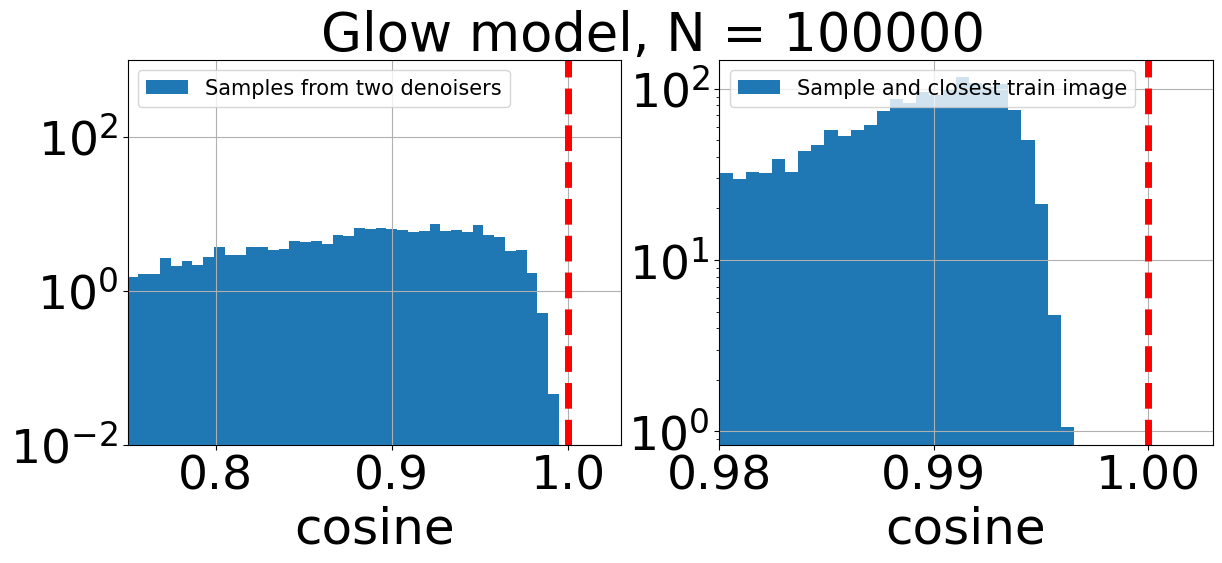

In [24]:
fig,ax = plt.subplots(1,2,figsize = (7*2,5))
fig.suptitle(f"Glow model, N = {ntrain}");
ax[0].hist(sims, bins = np.linspace(0.75,1.05 ,50), label='Samples from two denoisers', alpha = 1, density=True);
ax[0].legend(fontsize = 15);
ax[0].set_xlim(0.75,1.03)
ax[0].set_ylim(1e-2,1e3)
ax[0].axvline(x=1.0,c='r',lw=5,ls="--")
ax[0].set_yscale("log")
ax[0].set_xlabel("cosine")
ax[0].grid()

ax[1].hist(values , bins = np.linspace(0.98,1.01,50), label = 'Sample and closest train image', alpha = 1.0, density=True)
ax[1].set_xlim(0.98,1.003)
ax[1].legend(fontsize = 15);
ax[1].set_yscale("log")
ax[1].axvline(x=1.0,c='r',lw=5,ls="--")
ax[1].set_xlabel("cosine")
ax[1].grid()


plt.savefig("glow-cosine-AB_ATrain.pdf")